In [1]:
# Cell 1: Import thư viện
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

In [5]:
# Cell 2: Đọc dữ liệu sạch
df = pd.read_csv("../data/processed/telco_churn_clean.csv")

print("Kích thước dữ liệu:", df.shape)
display(df.head())

Kích thước dữ liệu: (7032, 20)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [6]:
# Cell 3: Mã hóa biến mục tiêu
df["Churn"] = df["Churn"].map({"No": 0, "Yes": 1})

print(df["Churn"].value_counts())
display(df.head())

Churn
0    5163
1    1869
Name: count, dtype: int64


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


In [7]:
# Cell 4: Tách X và y
X = df.drop(columns=["Churn"])
y = df["Churn"]

print("Kích thước X:", X.shape)
print("Kích thước y:", y.shape)

Kích thước X: (7032, 19)
Kích thước y: (7032,)


In [8]:
# Cell 5: Chia train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (5625, 19)
X_test : (1407, 19)
y_train: (5625,)
y_test : (1407,)


In [9]:
# Cell 6: Xác định nhóm biến
numerical_features = ["tenure", "MonthlyCharges", "TotalCharges", "SeniorCitizen"]
categorical_features = [col for col in X.columns if col not in numerical_features]

print("Biến số:", numerical_features)
print("Biến phân loại:", categorical_features)

Biến số: ['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen']
Biến phân loại: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [10]:
# Cell 7: Preprocessor cho Decision Tree
categorical_transformer = Pipeline(steps=[
    ("onehot", OneHotEncoder(drop="first", handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", "passthrough", numerical_features),
    ("cat", categorical_transformer, categorical_features)
])

In [11]:
# Cell 8: Tiền xử lý dữ liệu
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

if hasattr(X_train_processed, "toarray"):
    X_train_processed = X_train_processed.toarray()

if hasattr(X_test_processed, "toarray"):
    X_test_processed = X_test_processed.toarray()

print("X_train_processed shape:", X_train_processed.shape)
print("X_test_processed shape :", X_test_processed.shape)

X_train_processed shape: (5625, 30)
X_test_processed shape : (1407, 30)


In [13]:
# Cell 9: Huấn luyện Decision Tree cơ bản
dt_model = DecisionTreeClassifier(
    random_state=42,
    class_weight="balanced"
)

dt_model.fit(X_train_processed, y_train)

print("Huấn luyện Decision Tree thành công.")

Huấn luyện Decision Tree thành công.


In [14]:
# Cell 10: Dự đoán trên tập test
y_pred = dt_model.predict(X_test_processed)
y_prob = dt_model.predict_proba(X_test_processed)[:, 1]

print("Dự đoán xong.")

Dự đoán xong.


In [15]:
# Cell 11: Đánh giá mô hình
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print("=== Decision Tree (Basic) ===")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")

=== Decision Tree (Basic) ===
Accuracy : 0.7257
Precision: 0.4845
Recall   : 0.5000
F1-score : 0.4921
ROC-AUC  : 0.6541


In [16]:
# Cell 12: Classification Report
print("=== Classification Report ===")
print(classification_report(y_test, y_pred))

=== Classification Report ===
              precision    recall  f1-score   support

           0       0.82      0.81      0.81      1033
           1       0.48      0.50      0.49       374

    accuracy                           0.73      1407
   macro avg       0.65      0.65      0.65      1407
weighted avg       0.73      0.73      0.73      1407



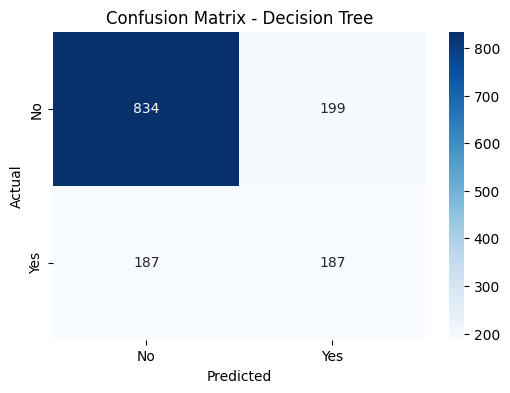

In [17]:
# Cell 13: Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No", "Yes"],
            yticklabels=["No", "Yes"])
plt.title("Confusion Matrix - Decision Tree")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

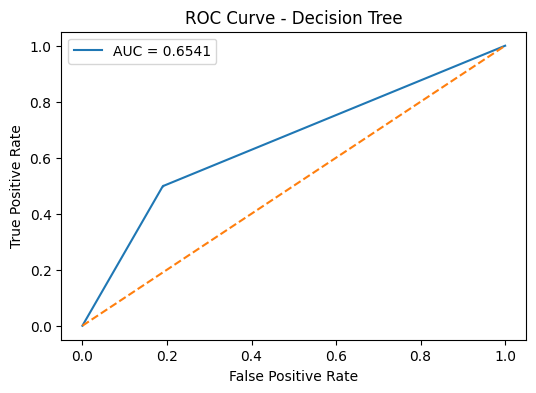

In [18]:
# Cell 14: ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Decision Tree")
plt.legend()
plt.show()

In [19]:
# Cell 15: Decision Tree có giới hạn để giảm overfitting
dt_model_tuned = DecisionTreeClassifier(
    random_state=42,
    class_weight="balanced",
    max_depth=5,
    min_samples_split=20,
    min_samples_leaf=10
)

dt_model_tuned.fit(X_train_processed, y_train)

print("Huấn luyện Decision Tree tuned thành công.")

Huấn luyện Decision Tree tuned thành công.


In [20]:
# Cell 16: Dự đoán bản tuned
y_pred_tuned = dt_model_tuned.predict(X_test_processed)
y_prob_tuned = dt_model_tuned.predict_proba(X_test_processed)[:, 1]

In [21]:
# Cell 17: Đánh giá bản tuned
accuracy_tuned = accuracy_score(y_test, y_pred_tuned)
precision_tuned = precision_score(y_test, y_pred_tuned)
recall_tuned = recall_score(y_test, y_pred_tuned)
f1_tuned = f1_score(y_test, y_pred_tuned)
roc_auc_tuned = roc_auc_score(y_test, y_prob_tuned)

print("=== Decision Tree (Tuned) ===")
print(f"Accuracy : {accuracy_tuned:.4f}")
print(f"Precision: {precision_tuned:.4f}")
print(f"Recall   : {recall_tuned:.4f}")
print(f"F1-score : {f1_tuned:.4f}")
print(f"ROC-AUC  : {roc_auc_tuned:.4f}")

=== Decision Tree (Tuned) ===
Accuracy : 0.7043
Precision: 0.4666
Recall   : 0.7834
F1-score : 0.5848
ROC-AUC  : 0.8175


In [22]:
# Cell 18: Classification Report bản tuned
print("=== Classification Report (Tuned) ===")
print(classification_report(y_test, y_pred_tuned))

=== Classification Report (Tuned) ===
              precision    recall  f1-score   support

           0       0.90      0.68      0.77      1033
           1       0.47      0.78      0.58       374

    accuracy                           0.70      1407
   macro avg       0.68      0.73      0.68      1407
weighted avg       0.78      0.70      0.72      1407



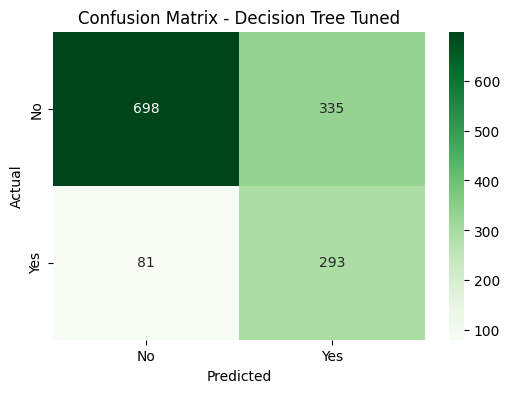

In [23]:
# Cell 19: Confusion Matrix bản tuned
cm_tuned = confusion_matrix(y_test, y_pred_tuned)

plt.figure(figsize=(6, 4))
sns.heatmap(cm_tuned, annot=True, fmt="d", cmap="Greens",
            xticklabels=["No", "Yes"],
            yticklabels=["No", "Yes"])
plt.title("Confusion Matrix - Decision Tree Tuned")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

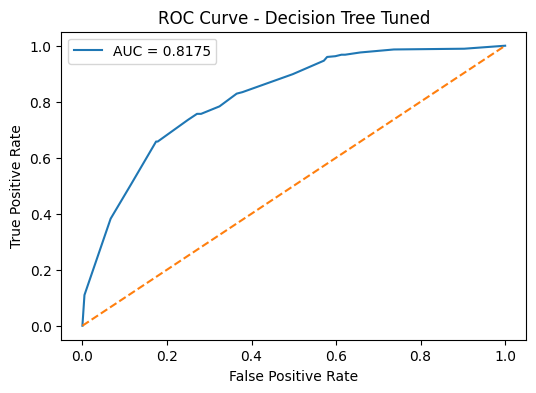

In [24]:
# Cell 20: ROC Curve bản tuned
fpr_tuned, tpr_tuned, _ = roc_curve(y_test, y_prob_tuned)

plt.figure(figsize=(6, 4))
plt.plot(fpr_tuned, tpr_tuned, label=f"AUC = {roc_auc_tuned:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Decision Tree Tuned")
plt.legend()
plt.show()

In [25]:
# Cell 21: Lấy tên feature
ohe = preprocessor.named_transformers_["cat"].named_steps["onehot"]
encoded_cat_features = ohe.get_feature_names_out(categorical_features)

feature_names = numerical_features + list(encoded_cat_features)

print("Tổng số feature:", len(feature_names))
print(feature_names[:20])

Tổng số feature: 30
['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen', 'gender_Male', 'Partner_Yes', 'Dependents_Yes', 'PhoneService_Yes', 'MultipleLines_No phone service', 'MultipleLines_Yes', 'InternetService_Fiber optic', 'InternetService_No', 'OnlineSecurity_No internet service', 'OnlineSecurity_Yes', 'OnlineBackup_No internet service', 'OnlineBackup_Yes', 'DeviceProtection_No internet service', 'DeviceProtection_Yes', 'TechSupport_No internet service', 'TechSupport_Yes']


In [26]:
# Cell 22: Feature importance
importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": dt_model_tuned.feature_importances_
}).sort_values(by="Importance", ascending=False)

display(importance_df.head(15))

,Feature,Importance
25,Contract_Two year,0.399105
24,Contract_One year,0.265012
10,InternetService_Fiber optic,0.102113
0,tenure,0.099004
23,StreamingMovies_Yes,0.034620
28,PaymentMethod_Electronic check,0.029879
1,MonthlyCharges,0.024943
2,TotalCharges,0.019360
18,TechSupport_No internet service,0.017885
6,Dependents_Yes,0.005273


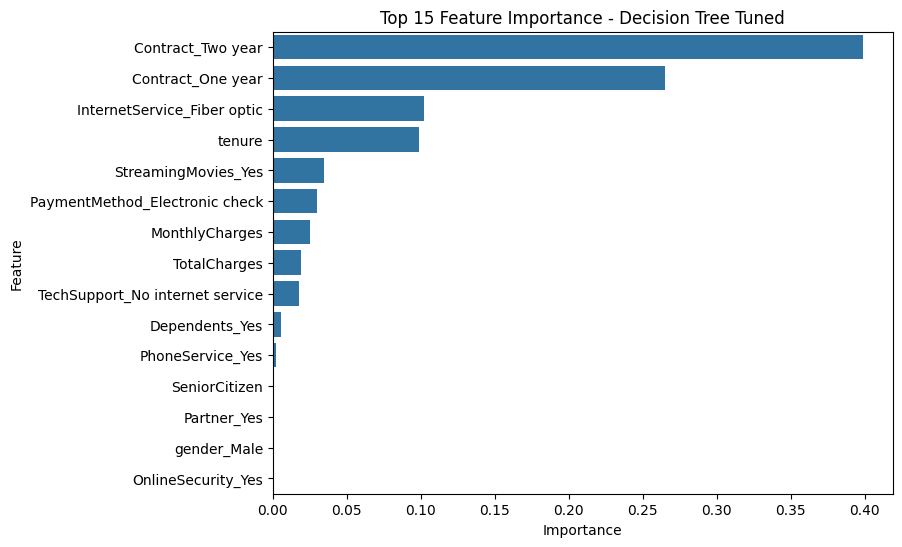

In [27]:
# Cell 23: Vẽ top feature importance
top_features = importance_df.head(15)

plt.figure(figsize=(8, 6))
sns.barplot(data=top_features, x="Importance", y="Feature")
plt.title("Top 15 Feature Importance - Decision Tree Tuned")
plt.show()

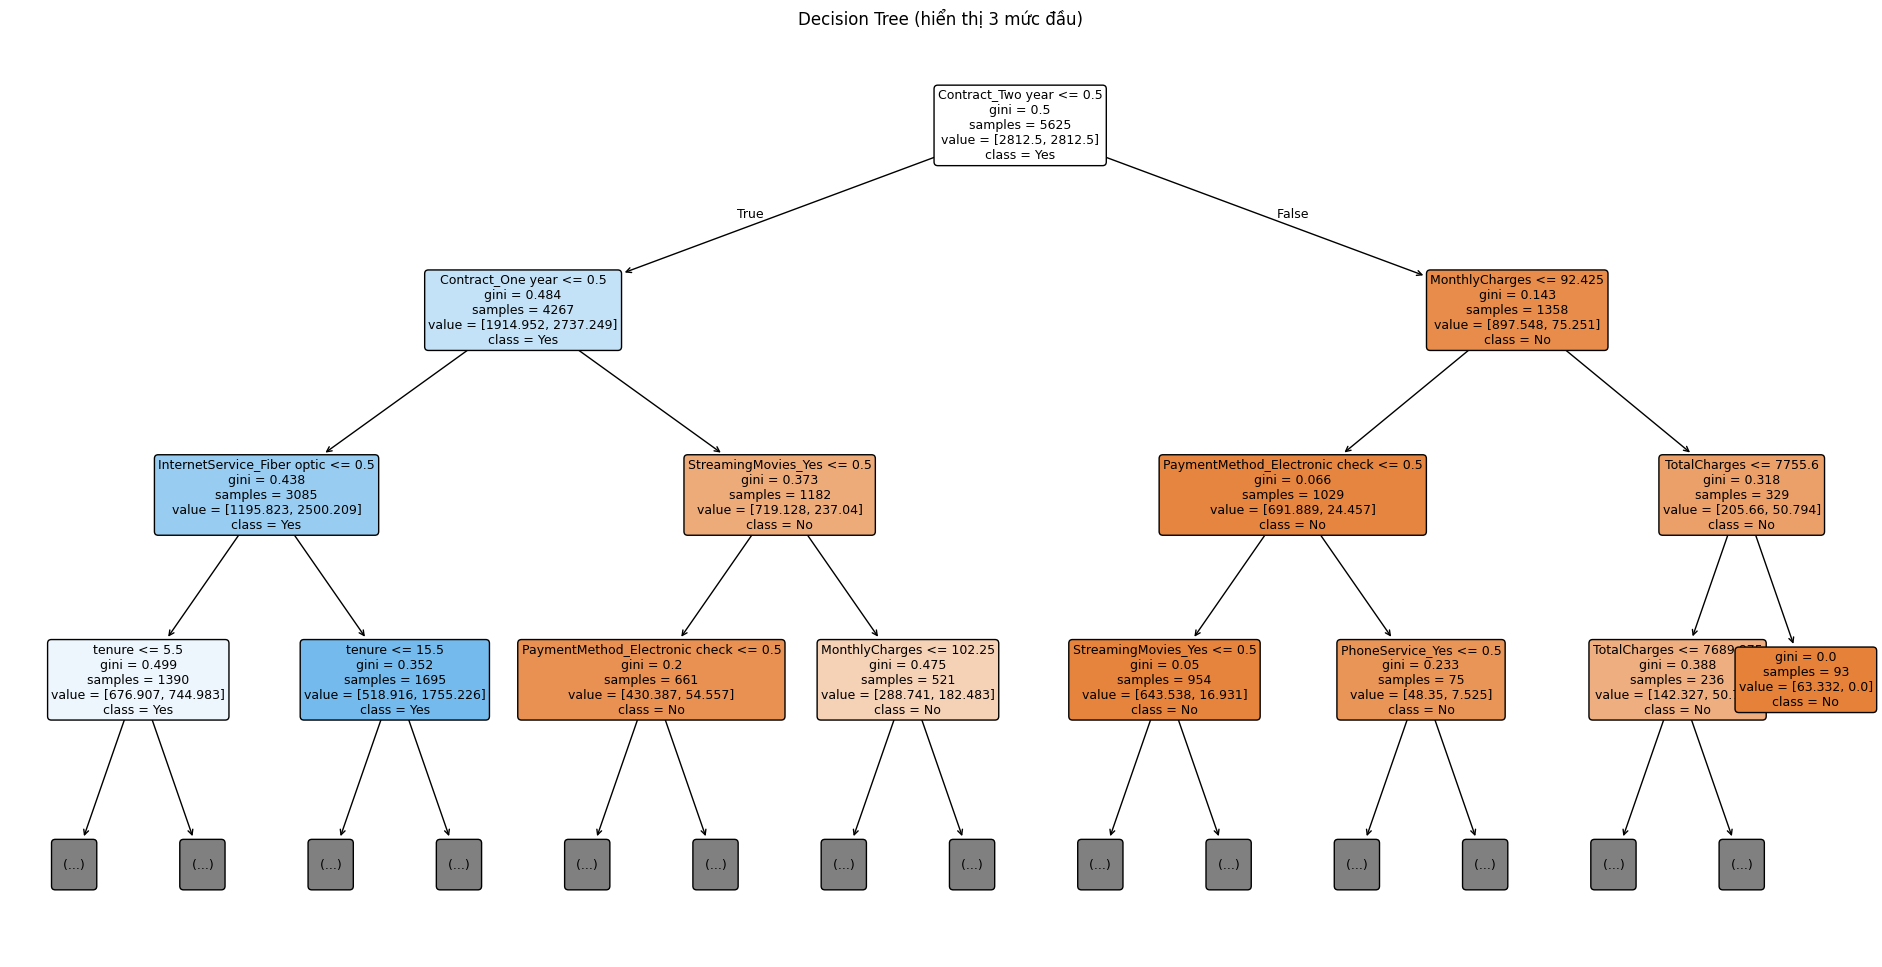

In [28]:
# Cell 24: Vẽ cây quyết định tuned
plt.figure(figsize=(24, 12))
plot_tree(
    dt_model_tuned,
    feature_names=feature_names,
    class_names=["No", "Yes"],
    filled=True,
    rounded=True,
    max_depth=3,
    fontsize=9
)
plt.title("Decision Tree (hiển thị 3 mức đầu)")
plt.show()

In [29]:
# Cell 25: Lưu kết quả
dt_results = pd.DataFrame({
    "Model": ["Decision Tree Basic", "Decision Tree Tuned"],
    "Accuracy": [accuracy, accuracy_tuned],
    "Precision": [precision, precision_tuned],
    "Recall": [recall, recall_tuned],
    "F1-score": [f1, f1_tuned],
    "ROC-AUC": [roc_auc, roc_auc_tuned]
})

display(dt_results)

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Decision Tree Basic,0.725657,0.484456,0.500000,0.492105,0.654147
1,Decision Tree Tuned,0.704335,0.466561,0.783422,0.584830,0.817536
